In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

data = pd.read_csv(
    "Task4.csv"
)

display(data.head())

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns)

,Country_Code,Squad,Num_Players,Age,Poss,MP,Starts,Min,90s,Gls,...,G_minus_PK,PK,PKatt,CrdY,CrdR,Gls_per90,Ast_per90,G_plus_A_per90,G_minus_PK_per90,G_plus_A_minus_PK_per90
0,dz,Algeria,22,27.3,61.0,4,44,360,4.0,5,...,5,0,0,3,0,1.25,0.75,2.00,1.25,2.00
1,ar,Argentina,24,29.6,57.6,8,88,810,9.0,18,...,17,1,3,15,1,2.00,1.33,3.33,1.89,3.22
2,au,Australia,23,25.3,41.0,4,44,390,4.3,2,...,2,0,0,5,0,0.46,0.23,0.69,0.46,0.69
3,at,Austria,20,28.8,45.0,4,44,360,4.0,5,...,4,1,1,5,0,1.25,1.00,2.25,1.00,2.00
4,be,Belgium,23,29.2,51.2,6,66,570,6.3,13,...,12,1,1,6,1,2.05,1.58,3.63,1.89,3.47


Dataset shape: (48, 22)

Columns:
Index(['Country_Code', 'Squad', 'Num_Players', 'Age', 'Poss', 'MP', 'Starts',
       'Min', '90s', 'Gls', 'Ast', 'G_plus_A', 'G_minus_PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'Gls_per90', 'Ast_per90', 'G_plus_A_per90',
       'G_minus_PK_per90', 'G_plus_A_minus_PK_per90'],
      dtype='object')


In [2]:
print("Data types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

Data types:
Country_Code                object
Squad                       object
Num_Players                  int64
Age                        float64
Poss                       float64
MP                           int64
Starts                       int64
Min                          int64
90s                        float64
Gls                          int64
Ast                          int64
G_plus_A                     int64
G_minus_PK                   int64
PK                           int64
PKatt                        int64
CrdY                         int64
CrdR                         int64
Gls_per90                  float64
Ast_per90                  float64
G_plus_A_per90             float64
G_minus_PK_per90           float64
G_plus_A_minus_PK_per90    float64
dtype: object

Missing values:
Country_Code               0
Squad                      0
Num_Players                0
Age                        0
Poss                       0
MP                         0
Starts       

In [3]:
data["Tournament_Group"] = np.where(
    data["MP"] >= 4,
    "Reached Knockout Stage",
    "Group Stage Eliminated"
)

print(
    data["Tournament_Group"].value_counts()
)

Tournament_Group
Reached Knockout Stage    32
Group Stage Eliminated    16
Name: count, dtype: int64


In [4]:
display(
    data[
        [
            "Squad",
            "Poss",
            "MP",
            "Tournament_Group"
        ]
    ].sort_values(
        "Tournament_Group"
    )
)

,Squad,Poss,MP,Tournament_Group
23,Iraq,38.3,3,Group Stage Eliminated
45,Uruguay,55.0,3,Group Stage Eliminated
44,Türkiye,66.3,3,Group Stage Eliminated
43,Tunisia,39.3,3,Group Stage Eliminated
37,Scotland,44.3,3,Group Stage Eliminated
36,Saudi Arabia,38.3,3,Group Stage Eliminated
35,Qatar,33.0,3,Group Stage Eliminated
32,Panama,45.7,3,Group Stage Eliminated
30,New Zealand,47.0,3,Group Stage Eliminated
26,Korea Republic,63.0,3,Group Stage Eliminated


In [5]:
knockout_population = data[
    data["Tournament_Group"]
    == "Reached Knockout Stage"
].copy()

eliminated_population = data[
    data["Tournament_Group"]
    == "Group Stage Eliminated"
].copy()

print(
    "Knockout-stage teams:",
    len(knockout_population)
)

print(
    "Group-stage eliminated teams:",
    len(eliminated_population)
)

Knockout-stage teams: 32
Group-stage eliminated teams: 16


In [6]:
knockout_sample = knockout_population.sample(
    n=16,
    random_state=42
)

eliminated_sample = eliminated_population.copy()

sample = pd.concat(
    [
        knockout_sample,
        eliminated_sample
    ],
    ignore_index=True
)

print(
    sample["Tournament_Group"].value_counts()
)

display(
    sample[
        [
            "Squad",
            "Poss",
            "MP",
            "Tournament_Group"
        ]
    ]
)

Tournament_Group
Reached Knockout Stage    16
Group Stage Eliminated    16
Name: count, dtype: int64


,Squad,Poss,MP,Tournament_Group
0,Sweden,46.3,4,Reached Knockout Stage
1,England,54.1,8,Reached Knockout Stage
2,Paraguay,30.0,5,Reached Knockout Stage
3,Germany,65.0,4,Reached Knockout Stage
4,Canada,54.4,5,Reached Knockout Stage
5,Colombia,57.8,5,Reached Knockout Stage
6,Switzerland,54.0,6,Reached Knockout Stage
7,Portugal,58.4,5,Reached Knockout Stage
8,Croatia,49.8,4,Reached Knockout Stage
9,Algeria,61.0,4,Reached Knockout Stage


In [7]:
descriptive_stats = (
    sample
    .groupby(
        "Tournament_Group"
    )["Poss"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
)

display(
    descriptive_stats.round(2)
)

,count,mean,median,standard_deviation,minimum,maximum
Tournament_Group,,,,,,
Group Stage Eliminated,16,43.49,41.00,10.23,30.7,66.3
Reached Knockout Stage,16,52.61,54.05,7.85,30.0,65.0


In [8]:
knockout_possession = knockout_sample[
    "Poss"
]

eliminated_possession = eliminated_sample[
    "Poss"
]

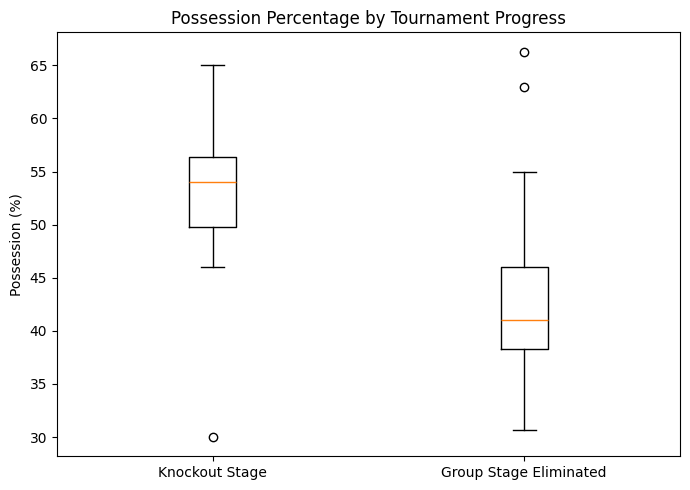

In [9]:
plt.figure(
    figsize=(7, 5)
)

plt.boxplot(
    [
        knockout_possession,
        eliminated_possession
    ],
    tick_labels=[
        "Knockout Stage",
        "Group Stage Eliminated"
    ]
)

plt.title(
    "Possession Percentage by Tournament Progress"
)

plt.ylabel(
    "Possession (%)"
)

plt.tight_layout()
plt.show()

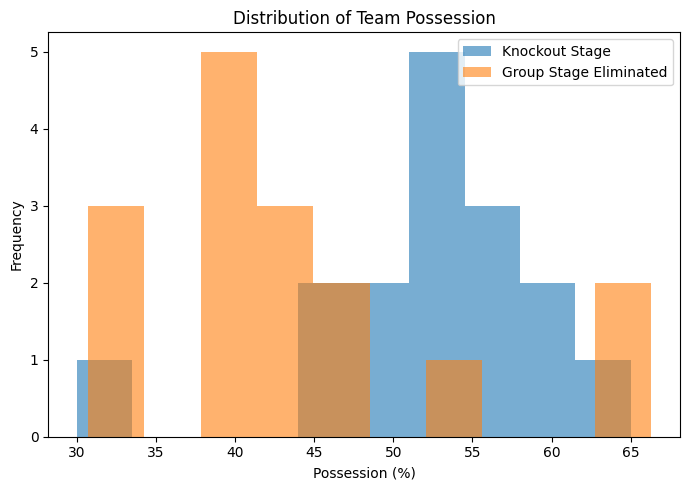

In [10]:
plt.figure(
    figsize=(7, 5)
)

plt.hist(
    knockout_possession,
    alpha=0.6,
    label="Knockout Stage"
)

plt.hist(
    eliminated_possession,
    alpha=0.6,
    label="Group Stage Eliminated"
)

plt.xlabel(
    "Possession (%)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Team Possession"
)

plt.legend()

plt.tight_layout()
plt.show()

In [12]:
def confidence_interval(values):

    n = len(values)

    mean = values.mean()

    standard_error = stats.sem(
        values
    )

    margin = (
        stats.t.ppf(
            0.975,
            df=n - 1
        )
        *
        standard_error
    )

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper


ko_mean, ko_lower, ko_upper = confidence_interval(
    knockout_possession
)

elim_mean, elim_lower, elim_upper = confidence_interval(
    eliminated_possession
)


print(
    "Knockout-stage mean:",
    round(ko_mean, 2)
)

print(
    "Knockout-stage 95% CI:",
    round(ko_lower, 2),
    "to",
    round(ko_upper, 2)
)


print(
    "\nGroup-stage eliminated mean:",
    round(elim_mean, 2)
)

print(
    "Group-stage eliminated 95% CI:",
    round(elim_lower, 2),
    "to",
    round(elim_upper, 2)
)

Knockout-stage mean: 52.61
Knockout-stage 95% CI: 48.42 to 56.79

Group-stage eliminated mean: 43.49
Group-stage eliminated 95% CI: 38.04 to 48.95


In [13]:
ko_shapiro = stats.shapiro(
    knockout_possession
)

elim_shapiro = stats.shapiro(
    eliminated_possession
)

print(
    "Knockout-stage Shapiro-Wilk p-value:",
    round(
        ko_shapiro.pvalue,
        4
    )
)

print(
    "Group-stage eliminated Shapiro-Wilk p-value:",
    round(
        elim_shapiro.pvalue,
        4
    )
)

Knockout-stage Shapiro-Wilk p-value: 0.0572
Group-stage eliminated Shapiro-Wilk p-value: 0.0481


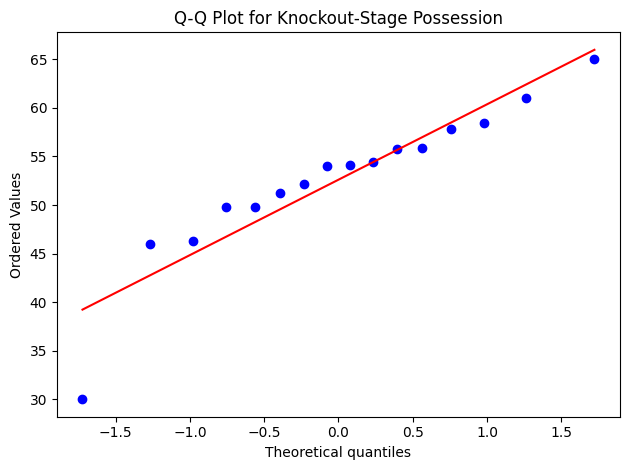

In [14]:
stats.probplot(
    knockout_possession,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot for Knockout-Stage Possession"
)

plt.tight_layout()
plt.show()

In [15]:
t_statistic, p_value = stats.ttest_ind(
    knockout_possession,
    eliminated_possession,
    equal_var=False
)

print(
    "t-statistic:",
    round(
        t_statistic,
        4
    )
)

print(
    "p-value:",
    round(
        p_value,
        4
    )
)

t-statistic: 2.8261
p-value: 0.0086


In [16]:
alpha = 0.05

if p_value < alpha:

    print(
        "Reject the null hypothesis."
    )

    print(
        "There is statistically significant evidence "
        "of a difference in mean possession percentage "
        "between knockout-stage teams and teams "
        "eliminated in the group stage."
    )

else:

    print(
        "Fail to reject the null hypothesis."
    )

    print(
        "There is insufficient statistical evidence "
        "of a difference in mean possession percentage "
        "between knockout-stage teams and teams "
        "eliminated in the group stage."
    )

Reject the null hypothesis.
There is statistically significant evidence of a difference in mean possession percentage between knockout-stage teams and teams eliminated in the group stage.


In [17]:
mean_difference = (
    knockout_possession.mean()
    -
    eliminated_possession.mean()
)

se_difference = np.sqrt(
    knockout_possession.var(ddof=1)
    / len(knockout_possession)
    +
    eliminated_possession.var(ddof=1)
    / len(eliminated_possession)
)

numerator = (
    knockout_possession.var(ddof=1)
    / len(knockout_possession)
    +
    eliminated_possession.var(ddof=1)
    / len(eliminated_possession)
) ** 2

denominator = (
    (
        knockout_possession.var(ddof=1)
        / len(knockout_possession)
    ) ** 2
    / (
        len(knockout_possession) - 1
    )
    +
    (
        eliminated_possession.var(ddof=1)
        / len(eliminated_possession)
    ) ** 2
    / (
        len(eliminated_possession) - 1
    )
)

welch_df = (
    numerator
    /
    denominator
)

t_critical = stats.t.ppf(
    0.975,
    df=welch_df
)

lower_difference = (
    mean_difference
    -
    t_critical
    * se_difference
)

upper_difference = (
    mean_difference
    +
    t_critical
    * se_difference
)

print(
    "Mean difference:",
    round(
        mean_difference,
        2
    ),
    "percentage points"
)

print(
    "95% CI for mean difference:",
    round(
        lower_difference,
        2
    ),
    "to",
    round(
        upper_difference,
        2
    ),
    "percentage points"
)

Mean difference: 9.11 percentage points
95% CI for mean difference: 2.51 to 15.72 percentage points


In [18]:
n1 = len(knockout_possession)
n2 = len(eliminated_possession)

sd1 = knockout_possession.std(
    ddof=1
)

sd2 = eliminated_possession.std(
    ddof=1
)

pooled_sd = np.sqrt(
    (
        (n1 - 1) * sd1**2
        +
        (n2 - 1) * sd2**2
    )
    /
    (n1 + n2 - 2)
)

cohens_d = (
    knockout_possession.mean()
    -
    eliminated_possession.mean()
) / pooled_sd

print(
    "Cohen's d:",
    round(
        cohens_d,
        2
    )
)

Cohen's d: 1.0
